In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import gdelt
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...
here
/home/luiyusen/projects/bptf_new


20

In [2]:
def process_date(date):
    """
    Queries the GDELT database and returns all events with a complete token (i.e. source, target country, action and time) by day.
    GDELT 2 only supports 2015 02 18 and onwards.
    Args:
        date: string. YYYY MM DD
    Returns:
        pandas dataframe with source, target country codes, action and day
    """
    try:
        ver = 1 if int(date[:4]) <= 2016 else 2
        gd = gdelt.gdelt(version=ver)
        results = gd.Search([date],table='events',coverage=True)
        results = results[['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions']]
        results.loc[:, 'EventBaseCode'] = results['EventBaseCode'].str[:2]
        results = results.dropna()
        # results = results.groupby(['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE'])
        # results = results.sum().reset_index()
        results = results[results['EventBaseCode'].str.isnumeric()]

        # print(f"Processed: {date} - {len(results)} rows")
        return results
    except Exception as e:
        print(f'Failed to process {date}: {e}')
        return pd.DataFrame(columns=['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions'])

In [3]:
filepath = 'gdelt1.csv'
if os.path.exists(filepath):
    gdelt1 = pd.read_csv(filepath)
    print(f'{filepath} exists')
else:
    gdelt1 = [process_date(str(year)) for year in tqdm(range(2000, 2015), desc='Downloading GDELT1')]
    gdelt1 = pd.concat(gdelt1)
    gdelt1.to_csv(filepath, index=False)

gdelt1.csv exists


In [4]:
# gdelt_filepaths = [os.path.join('GDELT', f) for f in os.listdir('GDELT')]

# gdelt = [pd.read_csv(gdelt_filepath) for gdelt_filepath in tqdm(gdelt_filepaths, desc='Reading GDELT data')]

# gdelt = pd.concat(gdelt)

# # combine the data
# # we stack the data since the downloaded GDELT data is from before 2015 and the bigquery one is post-2015
# # data = data[data['Database'] != 'GDELT']
# gdelt['Database'] = 'GDELT'

In [5]:
# lengths = gdelt['SQLDATE'].astype(str).apply(len).unique()
# # Convert to string (if not already done)
# gdelt['SQLDATE'] = gdelt['SQLDATE'].astype(str)

# # Create a boolean mask for rows that match the 8-digit pattern
# mask = gdelt['SQLDATE'].str.match(r'^\d{8}$')
# invalid_dates = gdelt.loc[~mask, 'SQLDATE']
# print("Invalid SQLDATE entries:\n", invalid_dates)

# gdelt['SQLDATE'] = pd.to_datetime(gdelt['SQLDATE'], format='%Y%m%d', errors='coerce')

# # Check how many values could not be parsed
# invalid_count = gdelt['SQLDATE'].isna().sum()
# print(f"Number of unparsed dates: {invalid_count}")

# gdelt['month'] = gdelt['SQLDATE'].dt.month
# month_counts = gdelt['month'].value_counts().sort_index()

# month_counts.plot(kind='bar')
# plt.show()

13380719
  Actor1CountryCode Actor2CountryCode  EventBaseCode    SQLDATE  NumMentions  \
0               AFG               AFG              2 2000-01-01            9   
1               AFG               AFG              8 2000-01-01            9   
2               AFG               ARE              3 2000-01-01            2   
3               AFG               IND              4 2000-01-01            7   
4               AFG               IND              4 2000-01-01            9   

   month  
0      1  
1      1  
2      1  
3      1  
4      1  


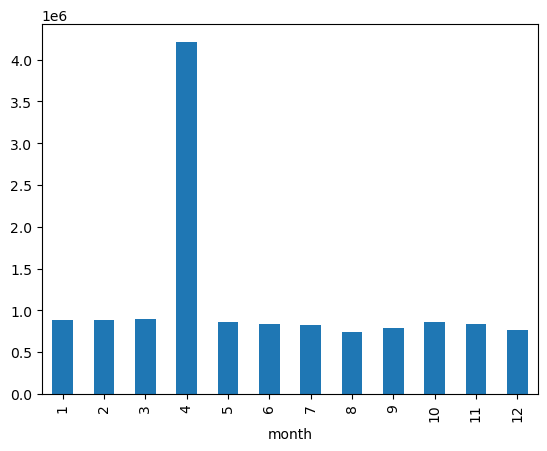

In [6]:
gdelt1['SQLDATE'] = pd.to_datetime(gdelt1['SQLDATE'].astype(str), format='%Y%m%d')
gdelt1 = gdelt1.dropna()
gdelt1['month'] = gdelt1['SQLDATE'].dt.month
month_counts = gdelt1['month'].value_counts().sort_index()
print(len(gdelt1))
month_counts.plot(kind='bar')
print(gdelt1.head())

In [7]:
folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
data = [pd.read_csv(data_filepath + filepath) for filepath in tqdm(files, desc = 'Reading data')]
data = pd.concat(data)
# data = data.sort_values(by='Num_Events', ascending=False)
years = [str(2000 + x) for x in range(0, 25)]
data = data[data['formatteddate'].str.startswith(tuple(years))]

Reading data:  92%|█████████▏| 95/103 [01:28<00:08,  1.07s/it]

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

   Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
12                 LVA                 NaN           1    2000-02-03   
13                 IRL                 NaN           1    2000-08-19   
14                 IRN                 NaN           1    2001-10-07   
15                 GRC                 NaN           1    2002-09-06   
16                 SGP                 NaN           1    2003-03-17   

    Num_Events Database  
12           1  TERRIER  
13           1  TERRIER  
14           1  TERRIER  
15           1  TERRIER  
16           1  TERRIER  


<Axes: xlabel='month'>

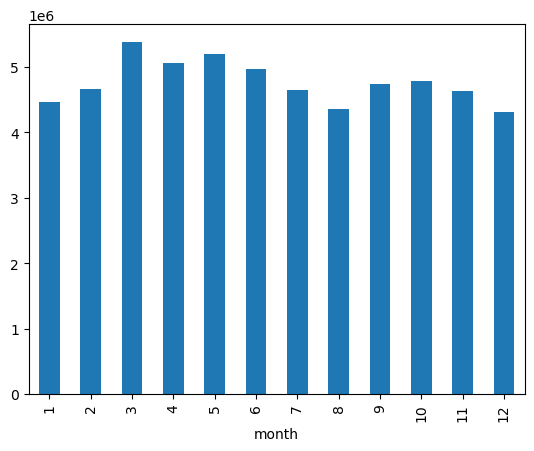

In [ ]:
print(data.head())
data['formatteddate'] = pd.to_datetime(data['formatteddate'], format='%Y-%m-%d')
data = data.dropna()
data['month'] = data['formatteddate'].dt.month
month_counts = data['month'].value_counts().sort_index()
month_counts.plot(kind='bar')

In [ ]:
gdelt1 = gdelt1.rename(
    columns={
        'Actor1CountryCode' : 'Source_Country_Code',
        'Actor2CountryCode' : 'Target_Country_Code',
        'EventBaseCode' : 'CAMEO_Code',
        'SQLDATE' : 'formatteddate',
        'NumMentions' : 'Num_Events'
    }
)
gdelt1['formatteddate'] = gdelt1['formatteddate'].dt.strftime('%Y-%m-%d')
gdelt1['Database'] = 'GDELT'
gdelt1 = gdelt1.dropna()
new_order = ['Source_Country_Code', 'Target_Country_Code', 'CAMEO_Code',
             'formatteddate', 'Num_Events', 'Database', 'month']
gdelt1 = gdelt1[new_order]
print(gdelt1.dtypes)

In [ ]:
print(gdelt1.head())
print(data.head())

  Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
0                 AFG                 AFG           2    2000-01-01   
1                 AFG                 AFG           8    2000-01-01   
2                 AFG                 ARE           3    2000-01-01   
3                 AFG                 IND           4    2000-01-01   
4                 AFG                 IND           4    2000-01-01   

   Num_Events Database  month  
0           9    GDELT      1  
1           9    GDELT      1  
2           2    GDELT      1  
3           7    GDELT      1  
4           9    GDELT      1  
      Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
25420                 USA                 ABW           1    2017-12-04   
25422                 USA                 ABW           1    2020-04-24   
25423                 PAN                 ABW           1    2019-10-10   
25424                 USA                 ABW           1    2017-10-06   
25425 

In [ ]:
combined_data = pd.concat([data, gdelt1])

In [ ]:
# Ensure 'formatteddate' is in datetime format and extract the year
data['formatteddate'] = pd.to_datetime(data['formatteddate'])
data['year'] = data['formatteddate'].dt.year

# --------------------------------------------
# Step 1: Compute duplicate counts per date, by year and Database
# --------------------------------------------
# Group by year and Database, then count occurrences of each 'formatteddate'
date_counts = data.groupby(['year', 'Database'])['formatteddate'].value_counts()

# For each date that appears more than once, the duplicate count is count - 1
duplicates_per_date = date_counts - 1

# Keep only dates that have duplicates (i.e. count > 0)
duplicates_per_date = duplicates_per_date[duplicates_per_date > 0]

# Sum the duplicate counts for each (year, Database) combination
duplicates_count = duplicates_per_date.groupby(level=[0, 1]).sum()

# --------------------------------------------
# Step 2: Compute total number of rows per (year, Database)
# --------------------------------------------
total_counts = data.groupby(['year', 'Database']).size()

# --------------------------------------------
# Step 3: Combine the totals and duplicates into a summary DataFrame
# --------------------------------------------
result = pd.DataFrame({
    'total_rows': total_counts,
    'duplicate_count': duplicates_count
})

# In case some groups have no duplicates, fill missing duplicate counts with 0
result['duplicate_count'] = result['duplicate_count'].fillna(0)

# Calculate the duplicate ratio (duplicate_count/total_rows)
result['duplicate_ratio'] = result['duplicate_count'] / result['total_rows']

print(result)

               total_rows  duplicate_count  duplicate_ratio
year Database                                              
2000 ICEWS         436351           435985         0.999161
     TERRIER       142681           142315         0.997435
2001 ICEWS         526679           526314         0.999307
     TERRIER       119508           119143         0.996946
2002 ICEWS         545167           544802         0.999330
     TERRIER       114531           114166         0.996813
2003 ICEWS         570447           570082         0.999360
     TERRIER       158737           158372         0.997701
2004 ICEWS         630368           630002         0.999419
     TERRIER       157049           156683         0.997670
2005 GDELT           1069              801         0.749298
     ICEWS         674246           673881         0.999459
     TERRIER       155097           154732         0.997647
2006 GDELT           1326             1019         0.768477
     ICEWS         731970           7316